In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score


In [56]:
test = pd.read_csv("/Users/hayashieijun/Desktop/airline-satisfaction-classification/data/test.csv")
train = pd.read_csv("/Users/hayashieijun/Desktop/airline-satisfaction-classification/data/train.csv")

In [57]:
train['Class'].unique()

array(['Eco Plus', 'Business', 'Eco'], dtype=object)

In [58]:
#preprocess data
def encode_gender(x):
    if x == 'Female':
        return 1
    elif x == 'Male':
        return 0
    else:
        return -1
    
def encode_customer_type(x):
    if x == 'Loyal Customer':
        return 1
    elif x == 'disloyal Customer':
        return 0
    else:
        return -1
    
def encode_type_of_travel(x):
    if x == 'Business travel':
        return 1
    elif x == 'Personal Travel':
        return 0
    else:
        return -1
    
def encode_class(x):
    if x == 'Business':
        return 2
    elif x == 'Eco Plus':
        return 1
    elif x == 'Eco':
        return 0
    else:
        return -1
    
def encode_satisfaction(x):
    if x == 'satisfied':
        return 1
    elif x == 'neutral or dissatisfied':
        return 0
    else:
        return -1 

In [59]:
def preprocess_data(df):
    #drop meaningless columns
    df = df.drop(columns=['id', 'Unnamed: 0'])

    #encode
    df['Gender'] = df['Gender'].apply(encode_gender)
    df['Customer Type'] = df['Customer Type'].apply(encode_customer_type)
    df['Type of Travel'] = df['Type of Travel'].apply(encode_type_of_travel)
    df['Class'] = df['Class'].apply(encode_class)
    df['satisfaction'] = df['satisfaction'].apply(encode_satisfaction)

    #feature engineering
    df['Age Group'] = pd.cut(df['Age'], bins=[0, 18, 30, 50, 100], labels=[0, 1, 2, 3])
    df['Flight Distance Group'] = pd.cut(df['Flight Distance'], bins=[0, 500, 1500, 3000, 5000], labels=[0, 1, 2, 3])
    df['Total Delay']  = df[['Departure Delay in Minutes', 'Arrival Delay in Minutes']].sum(axis=1)
    df['Service Score Average'] = (df['On-board service'] + df['Checkin service'] + df['Inflight service'] + df['Inflight wifi service']) / 4

    #drop original columns after feature engineering and original encoded columns
    df = df.drop(columns = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'On-board service', 'Checkin service', 'Inflight service', 'Inflight wifi service', 'Customer Type', 'Type of Travel'], errors='ignore')

    #drop the columns that are not used for modeling
    df = df.drop(columns = ['Departure/Arrival time convenient', 'Gate location'], errors='ignore')
    return df

train_processed = preprocess_data(train)
test_processed = preprocess_data(test)

In [60]:
#split data
X_train = train_processed.drop(columns=['satisfaction'], errors='ignore')
y_train = train_processed['satisfaction']
X_test = test_processed.drop(columns=['satisfaction'], errors='ignore')
y_test = test_processed['satisfaction']

In [61]:
#standardize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

ROC_AUC = 0.8258882684439975
              precision    recall  f1-score   support

           0    0.83521   0.87154   0.85299     14573
           1    0.82617   0.78023   0.80254     11403

    accuracy                        0.83146     25976
   macro avg    0.83069   0.82589   0.82777     25976
weighted avg    0.83124   0.83146   0.83084     25976



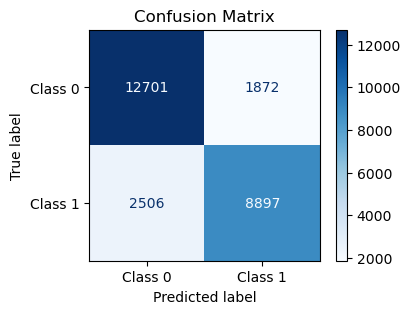

In [62]:
def run_model(model, X_train, y_train, X_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    roc_auc = roc_auc_score(y_test, y_pred)
    print("ROC_AUC = {}".format(roc_auc))
    print(classification_report(y_test,y_pred,digits=5))
    #confusion matrix
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=['Class 0', 'Class 1'], cmap='Blues', ax=ax)
    plt.title('Confusion Matrix')
    plt.show()
    return model, y_pred

logistic_model, logistic_predictions = run_model(LogisticRegression(), X_train, y_train, X_test)

--- Dummy Baseline ---
ROC_AUC = 0.5
              precision    recall  f1-score   support

           0    0.56102   1.00000   0.71878     14573
           1    0.00000   0.00000   0.00000     11403

    accuracy                        0.56102     25976
   macro avg    0.28051   0.50000   0.35939     25976
weighted avg    0.31474   0.56102   0.40325     25976



/Users/hayashieijun/Desktop/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hayashieijun/Desktop/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hayashieijun/Desktop/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

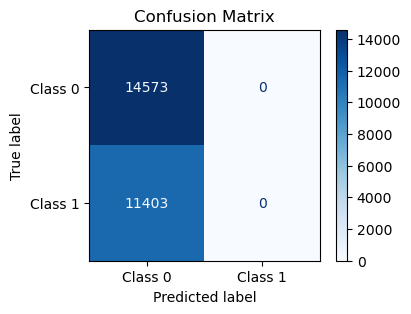


--- Logistic Regression Baseline ---
ROC_AUC = 0.8258882684439975
              precision    recall  f1-score   support

           0    0.83521   0.87154   0.85299     14573
           1    0.82617   0.78023   0.80254     11403

    accuracy                        0.83146     25976
   macro avg    0.83069   0.82589   0.82777     25976
weighted avg    0.83124   0.83146   0.83084     25976



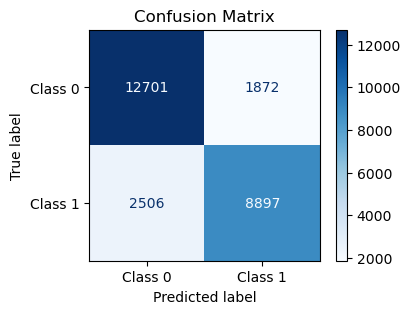

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier


dummy_model = DummyClassifier(strategy="most_frequent")
print("--- Dummy Baseline ---")
run_model(dummy_model, X_train, y_train, X_test)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

baseline_model = make_pipeline(StandardScaler(), LogisticRegression())
print("\n--- Logistic Regression Baseline ---")
baseline_model, baseline_preds = run_model(baseline_model, X_train, y_train, X_test)

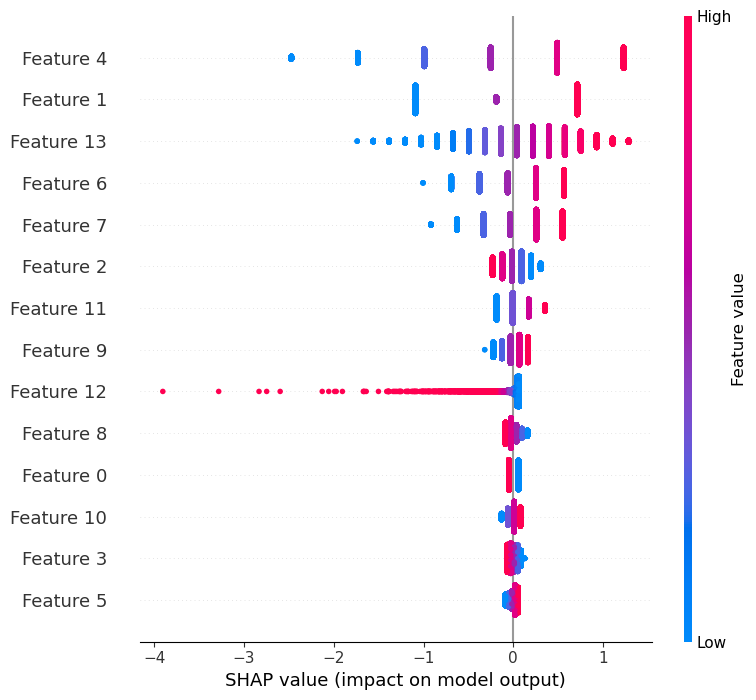

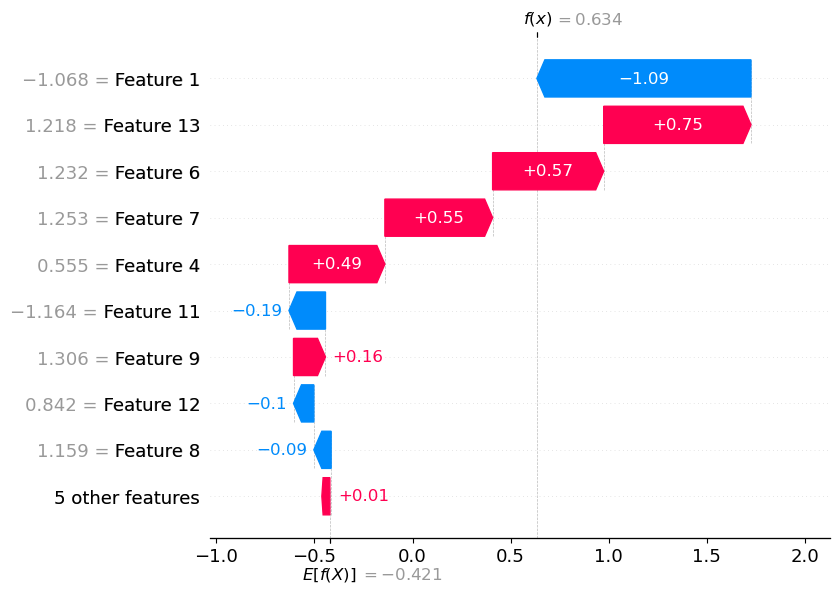

In [64]:
import shap

explainer = shap.LinearExplainer(logistic_model, X_train)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)
shap.plots.waterfall(explainer(X_test)[0])

# <font color=#00BBFF> PIPELINE </font>

In [65]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression

# ==========================================
# 1. Data Preparation
# ==========================================
df = pd.read_csv("/Users/hayashieijun/Desktop/airline-satisfaction-classification/data/test.csv")

# Map target to binary (Logistic Regression needs numeric labels)
y = df['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})
X = df.drop(columns=['satisfaction'])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 2. Custom Feature Engineering Function
# ==========================================
def custom_feature_engineering(df):
    df = df.copy()
    
    # Binning continuous variables
    df['Age Group'] = pd.cut(df['Age'], bins=[0, 18, 30, 50, 100], labels=[0, 1, 2, 3]).astype(float)
    df['Flight Distance Group'] = pd.cut(df['Flight Distance'], bins=[0, 500, 1500, 3000, 5000], labels=[0, 1, 2, 3]).astype(float)
    
    # Total Delay (Handling NaNs is crucial for Logistic Regression)
    df['Total Delay'] = df['Departure Delay in Minutes'] + df['Arrival Delay in Minutes'].fillna(0)
    
    # Average Service Score
    service_cols = ['On-board service', 'Checkin service', 'Inflight service', 'Inflight wifi service']
    df['Service Score Average'] = df[service_cols].mean(axis=1)
    
    # Drop columns that are no longer needed for modeling
    # Note: We keep Gender, Customer Type, etc. here because they will be encoded in the next step
    cols_to_drop = [
        'id', 'Unnamed: 0', 'Age', 'Flight Distance', 
        'Departure Delay in Minutes', 'Arrival Delay in Minutes',
        'On-board service', 'Checkin service', 'Inflight service', 'Inflight wifi service',
        'Departure/Arrival time convenient', 'Gate location'
    ]
    return df.drop(columns=cols_to_drop, errors='ignore')

# Wrap the function for use in the Pipeline
feature_engineer = FunctionTransformer(custom_feature_engineering)

# ==========================================
# 3. Categorical Encoding & Preprocessing
# ==========================================
# Define the categorical columns and their order for OrdinalEncoder
categorical_features = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
ordinal_categories = [
    ['Male', 'Female'],                    
    ['disloyal Customer', 'Loyal Customer'], 
    ['Personal Travel', 'Business travel'],  
    ['Eco', 'Eco Plus', 'Business']      
]

preprocessor = ColumnTransformer(
    transformers=[
        ('ord_encode', OrdinalEncoder(categories=ordinal_categories), categorical_features)
    ],
    remainder='passthrough'
)

# ==========================================
# 4. Final Pipeline with Logistic Regression
# ==========================================
# Logistic Regression is sensitive to feature scale, so StandardScaler is a must.
full_pipeline = Pipeline(steps=[
    ('feature_eng', feature_engineer),
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, solver='lbfgs', C=0.1))
])

# Train the model
full_pipeline.fit(X_train, y_train)

# Save to .pkl
joblib.dump(full_pipeline, "../pipelines/logistic_regression_pipeline.pkl")
print("Pipeline saved as logistic_regression_pipeline.pkl")

Pipeline saved as logistic_regression_pipeline.pkl


In [66]:
y_pred = full_pipeline.predict(X_test)

# 2. Check the performance
from sklearn.metrics import accuracy_score, classification_report
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"F1 Macro: {f1_score(y_test, y_pred, average='macro'):.4f}")

Test Accuracy: 0.8626

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.89      0.88      2945
           1       0.85      0.83      0.84      2251

    accuracy                           0.86      5196
   macro avg       0.86      0.86      0.86      5196
weighted avg       0.86      0.86      0.86      5196

F1 Macro: 0.8596


In [67]:
import joblib


loaded_pipeline = joblib.load("/Users/hayashieijun/Desktop/airline-satisfaction-classification/pipelines/logistic_regression_pipeline.pkl")

test_data = pd.read_csv('/Users/hayashieijun/Desktop/airline-satisfaction-classification/data/test.csv')
x_test = test_data.drop(columns=['Unnamed: 0', 'id'])
y_test = test_data['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})


loaded_preds = loaded_pipeline.predict(x_test)


print("--- Loaded Pipeline Performance ---")
print(f"Accuracy: {accuracy_score(y_test, loaded_preds):.4f}")
print(f"F1 Macro: {f1_score(y_test, loaded_preds, average='macro'):.4f}")

--- Loaded Pipeline Performance ---
Accuracy: 0.8694
F1 Macro: 0.8668


# <font color=#00BBFF> PLOTS </font>

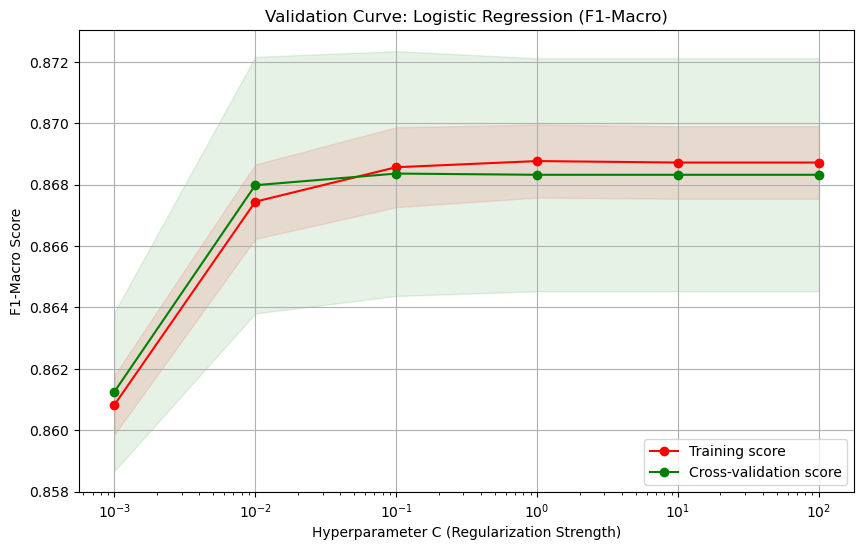

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve

param_range = np.logspace(-3, 2, 6)

train_scores, test_scores = validation_curve(
    full_pipeline, 
    X_train, y_train, 
    param_name="classifier__C",  
    param_range=param_range,
    cv=5, 
    scoring="f1_macro", 
    n_jobs=-1
)

#calculate mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)


plt.figure(figsize=(10, 6))
plt.semilogx(param_range, train_mean, label="Training score", color="red", marker='o')
plt.semilogx(param_range, test_mean, label="Cross-validation score", color="green", marker='o')


plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.1, color="red")
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.1, color="green")

plt.title("Validation Curve: Logistic Regression (F1-Macro)")
plt.xlabel("Hyperparameter C (Regularization Strength)")
plt.ylabel("F1-Macro Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [69]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs'] 
}

grid_search = GridSearchCV(
    full_pipeline, 
    param_grid, 
    cv=5, 
    scoring='f1_macro', 
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'classifier__C': [0.001, 0.01, ...], 'classifier__penalty': ['l2'], 'classifier__solver': ['lbfgs']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,func,<function cus...t 0x16429dee0>


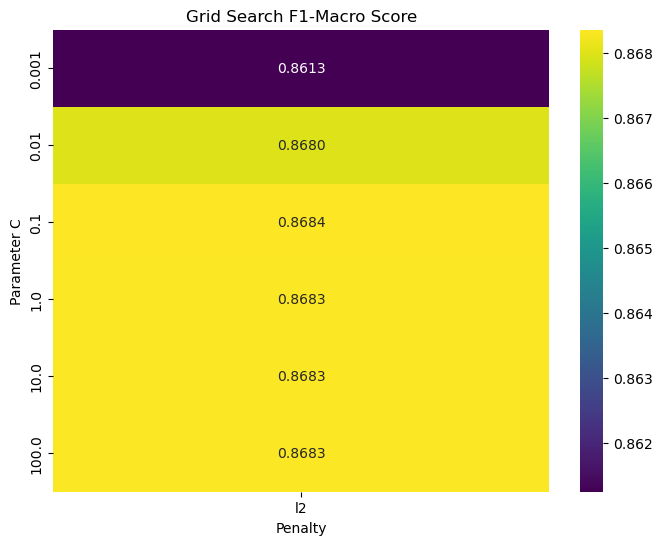

In [70]:
import seaborn as sns
import pandas as pd

results_df = pd.DataFrame(grid_search.cv_results_)

viz_data = results_df.pivot(index='param_classifier__C', 
                           columns='param_classifier__penalty', 
                           values='mean_test_score')

plt.figure(figsize=(8, 6))
sns.heatmap(viz_data, annot=True, cmap='viridis', fmt='.4f')
plt.title('Grid Search F1-Macro Score')
plt.ylabel('Parameter C')
plt.xlabel('Penalty')
plt.show()

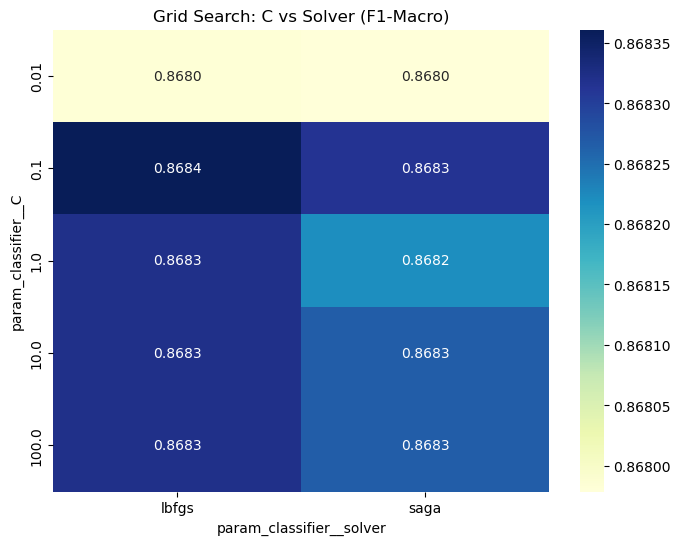

In [71]:
from sklearn.model_selection import GridSearchCV
import seaborn as sns

param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['lbfgs', 'saga'],  # 比較不同演算法
    'classifier__penalty': ['l2']             # 固定 l2 比較不同 solver
}

grid_search = GridSearchCV(
    full_pipeline, 
    param_grid, 
    cv=5, 
    scoring='f1_macro', 
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


results_df = pd.DataFrame(grid_search.cv_results_)
viz_data = results_df.pivot(index='param_classifier__C', 
                           columns='param_classifier__solver', 
                           values='mean_test_score')

plt.figure(figsize=(8, 6))
sns.heatmap(viz_data, annot=True, cmap='YlGnBu', fmt='.4f')
plt.title('Grid Search: C vs Solver (F1-Macro)')
plt.show()

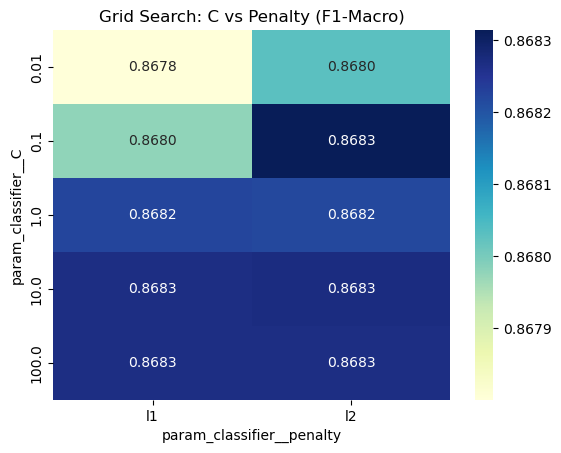

In [72]:
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['saga'],  
    'classifier__max_iter': [2000]   
}

grid_search = GridSearchCV(
    full_pipeline, 
    param_grid, 
    cv=5, 
    scoring='f1_macro', 
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


viz_data = pd.DataFrame(grid_search.cv_results_).pivot(
    index='param_classifier__C', 
    columns='param_classifier__penalty', 
    values='mean_test_score'
)

sns.heatmap(viz_data, annot=True, cmap='YlGnBu', fmt='.4f')
plt.title('Grid Search: C vs Penalty (F1-Macro)')
plt.show()

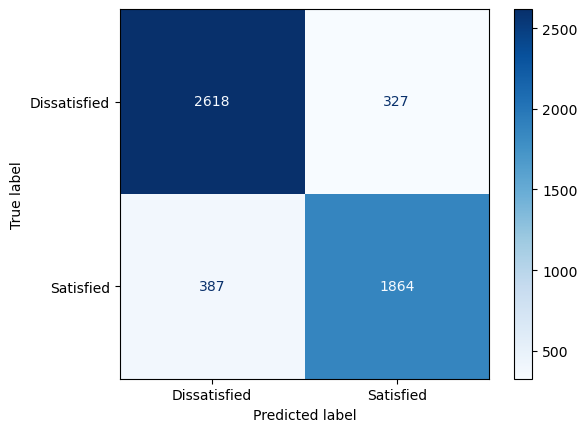

In [73]:
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_pred = full_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dissatisfied', 'Satisfied'])
disp.plot(cmap='Blues', values_format='d',)
plt.show()

/var/folders/cq/hl3j32w16cb80bz20lcyxw4m0000gn/T/ipykernel_61974/2926756240.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette='RdBu_r')


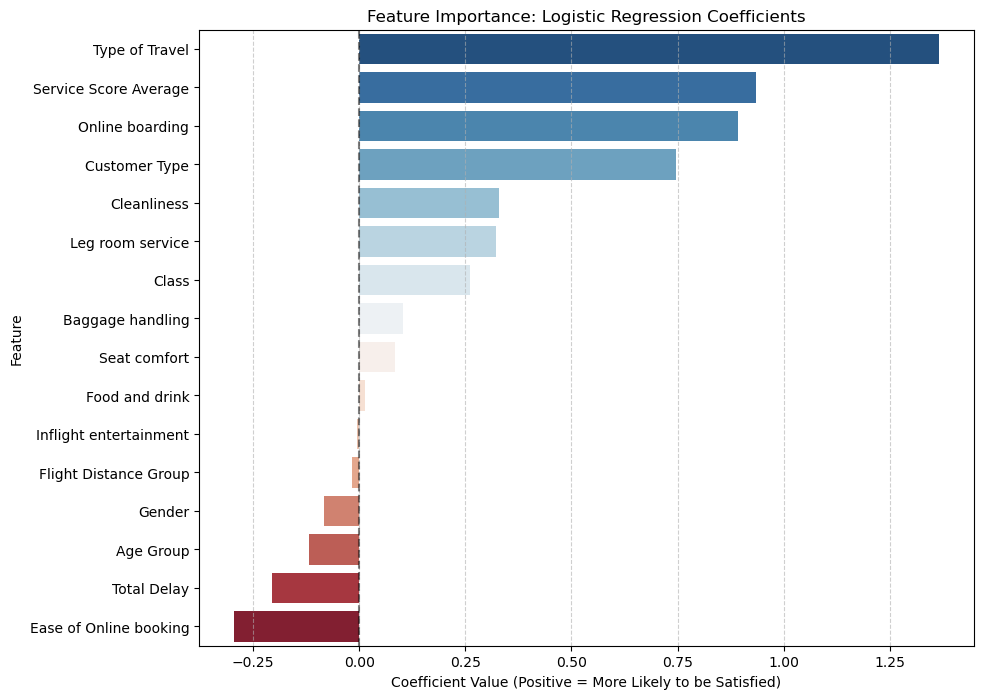

Exception ignored in: <function ResourceTracker.__del__ at 0x1039ed580>
Traceback (most recent call last):
  File "/Users/hayashieijun/Desktop/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/hayashieijun/Desktop/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/hayashieijun/Desktop/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1045a1580>
Traceback (most recent call last):
  File "/Users/hayashieijun/Desktop/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/hayashieijun/Desktop/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/hayashieijun/Desktop/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessErr

In [74]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

encoded_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
temp_df = feature_engineer.transform(X_train.head(1))
remaining_cols = [col for col in temp_df.columns if col not in encoded_cols]
all_feature_names = encoded_cols + remaining_cols


model_coefs = full_pipeline.named_steps['classifier'].coef_[0]


importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': model_coefs
}).sort_values(by='Coefficient', ascending=False)


plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette='RdBu_r')
plt.title("Feature Importance: Logistic Regression Coefficients")
plt.xlabel("Coefficient Value (Positive = More Likely to be Satisfied)")
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

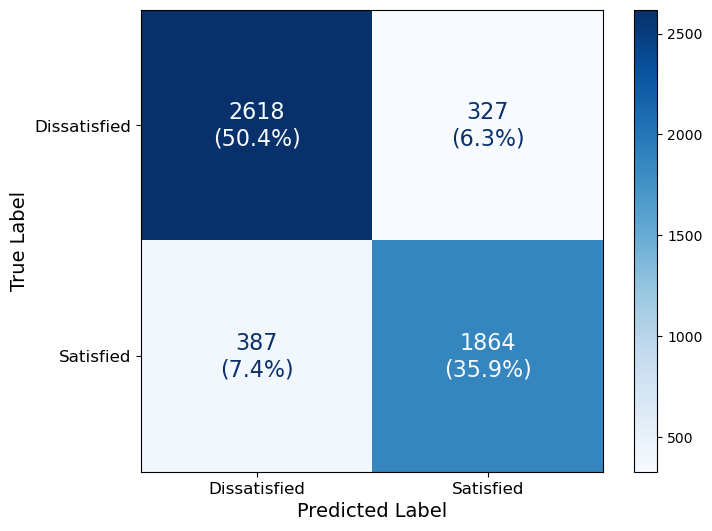

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

cm_perc = cm.astype('float') / cm.sum() * 100

labels = [f"{v}\n({p:.1f}%)" for v, p in zip(cm.flatten(), cm_perc.flatten())]
labels = np.asarray(labels).reshape(2, 2)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dissatisfied', 'Satisfied'])

disp.plot(cmap='Blues', values_format='', ax=ax) 

for i in range(2):
    for j in range(2):
        disp.text_[i, j].set_text(labels[i, j])
        disp.text_[i, j].set_fontsize(16) 
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)

plt.show()

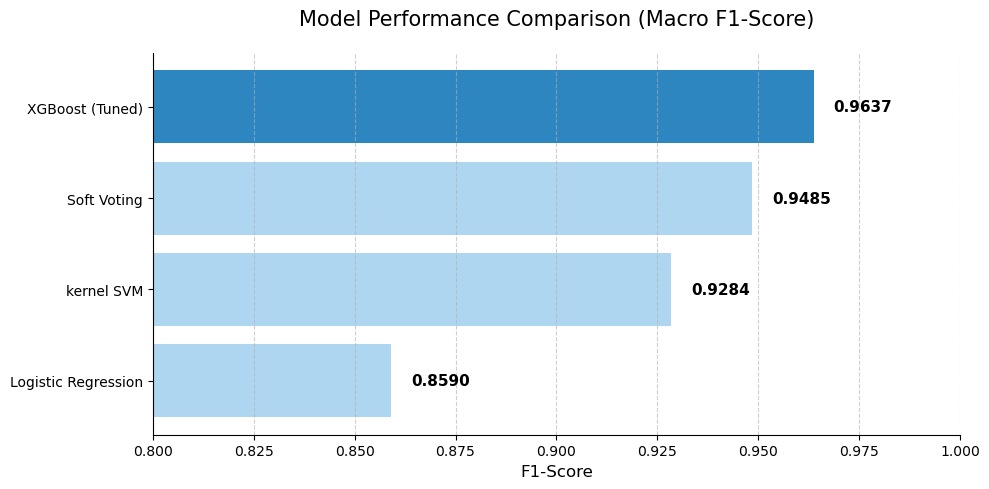

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

# 直接輸入你表格中的數據
data = {
    'Model': ['XGBoost (Tuned)', 'Soft Voting', 'kernel SVM', 'Logistic Regression'],
    'F1_Macro': [0.9637, 0.9485, 0.9284, 0.8590]
}

df = pd.DataFrame(data).sort_values(by='F1_Macro', ascending=True)

plt.figure(figsize=(10, 5))
# 設定顏色：最高分用深藍色，其餘用淺藍色
colors = ['#AED6F1' if x < max(df['F1_Macro']) else '#2E86C1' for x in df['F1_Macro']]

bars = plt.barh(df['Model'], df['F1_Macro'], color=colors)

# 在條形末端加上數值標籤
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', va='center', fontweight='bold', fontsize=11)

plt.xlim(0.8, 1.0) # 截短 x 軸讓差距明顯
plt.title('Model Performance Comparison (Macro F1-Score)', fontsize=15, pad=20)
plt.xlabel('F1-Score', fontsize=12)
plt.gca().spines['top'].set_visible(False) # 去除上方邊框
plt.gca().spines['right'].set_visible(False) # 去除右方邊框
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

/Users/hayashieijun/Desktop/anaconda3/lib/python3.13/pickle.py:1760: UserWarning: [12:55:45] WARNING: /Users/runner/work/xgboost/xgboost/src/gbm/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


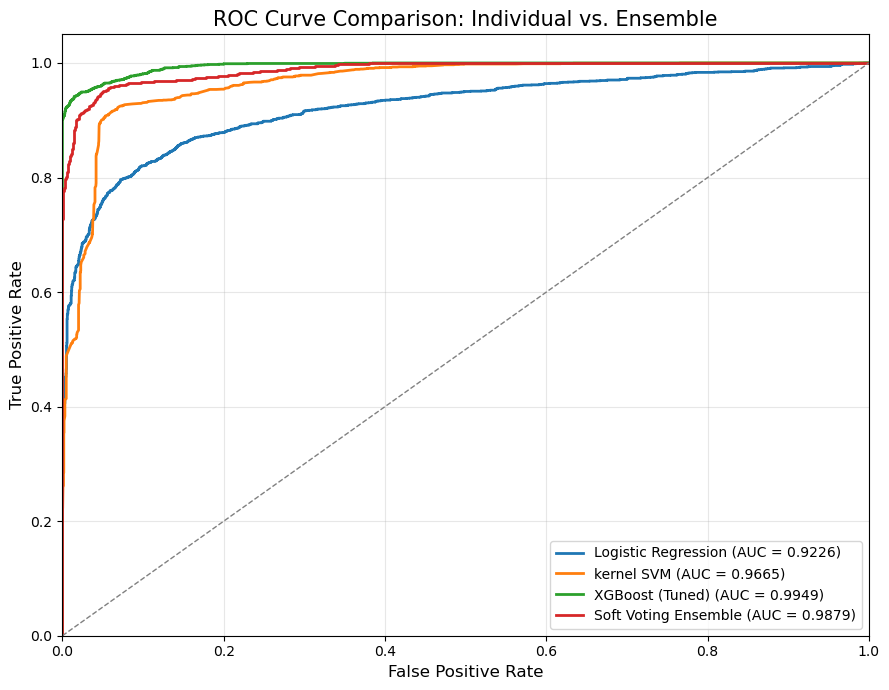

In [79]:
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. 讀取所有已存好的 Pipeline (確保路徑正確)
# 這裡假設你的檔案都在 pipelines 資料夾下
lr_pipeline = joblib.load('/Users/hayashieijun/Desktop/airline-satisfaction-classification/pipelines/logistic_regression_pipeline.pkl')
svm_pipeline = joblib.load('/Users/hayashieijun/Desktop/airline-satisfaction-classification/pipelines/svm_pipeline.pkl')
xgb_pipeline = joblib.load('/Users/hayashieijun/Desktop/airline-satisfaction-classification/pipelines/xgb_pipeline.pkl')

# 2. 取得各模型的預測機率 (取類別 1 的機率)
# 注意：SVM 如果當初訓練沒設 probability=True，這步會報錯
y_score_lr = lr_pipeline.predict_proba(X_test)[:, 1]
y_score_svm = svm_pipeline.predict_proba(X_test)[:, 1]
y_score_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

# 3. 計算 Soft Voting 的機率 (三個模型的平均值)
y_score_soft = (y_score_lr + y_score_svm + y_score_xgb) / 3

# 4. 準備繪圖數據
models_scores = {
    'Logistic Regression': y_score_lr,
    'kernel SVM': y_score_svm,
    'XGBoost (Tuned)': y_score_xgb,
    'Soft Voting Ensemble': y_score_soft
}

# 5. 開始畫 ROC 圖
plt.figure(figsize=(9, 7))

for name, y_score in models_scores.items():
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

# 畫對角基準線
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')

# 圖表美化
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison: Individual vs. Ensemble', fontsize=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()